## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
Regression predicts a numeric outcome, such as baseline sales. Classification predicts a category, such as class. Use regression for a numeric target, such as price, and classification for a categorical target, such as survival.

2. What is a confusion table? What does it help us understand about a model's performance?
A confusion matrix counts predictions by actual class and predicted class. Here, rows are actual classes and columns are predictions. Diagonal cells count correct predictions. Off-diagonal cells count misclassifications. Accuracy does not show which classes are misclassified or account for different costs of false positives and false negatives. Check the confusion matrix as well.

3. What does the SSE quantify about a particular model?
For regression, the residual for observation $i$ is $e_i=y_i-\hat{y}(x_i,k)$. A residual gives the direction and size of a prediction error. For $n_{\mathrm{valid}}$ validation observations, add the squared residuals: $SSE(k)=\sum_{i=1}^{n_{\mathrm{valid}}}(y_i-\hat{y}(x_i,k))^2=\sum_{i=1}^{n_{\mathrm{valid}}}e_i^2$. Lower validation SSE means smaller errors on this validation set.

4. What are overfitting and underfitting?
Very small $k$ can overfit noise in the training data. Very large $k$ can underfit by giving nearly the same prediction for every observation. A model can fit its training data well by fitting noise in that sample.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
Generalization is a model's ability to predict well on data that were not used to fit it. A hyperparameter is a setting we choose before fitting the model, such as $k$. Choosing $k$ by training error alone can lead to overfitting. We need to evaluate predictions on observations that were not used to fit the model. We split the data to check how well the model predicts new observations: Fit models on a training set. Compare their predictions on a separate validation set. Validation error helps estimate performance on future data from a similar source. We choose $k$ using validation SSE. Training SSE alone would favor a smaller $k$.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
For a class label, we predict the most common class among the nearest neighbors. For a probability distribution, we estimate each class proportion by dividing its neighbor count by $k$. (The slides do not define the strengths and weaknesses, so the rest of this answer is in my own words.) A class label is simple and easy to act on, but it hides how sure the model is, so a close vote looks the same as a unanimous one. A probability distribution shows the model's confidence and lets us set our own cutoffs, but it is harder to read, and in $k$-NN the proportions are rough because they can only be 0, 1/k, 2/k, and so on.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Olympia Sauerwein

**Date:** 10/3/26

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/land_mines.csv')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [8]:
print(df.shape)
print(df.isna().sum())
print(df.describe())
print(df['mine_type'].value_counts().sort_index())
print(df.groupby('mine_type').mean())

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
            voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923


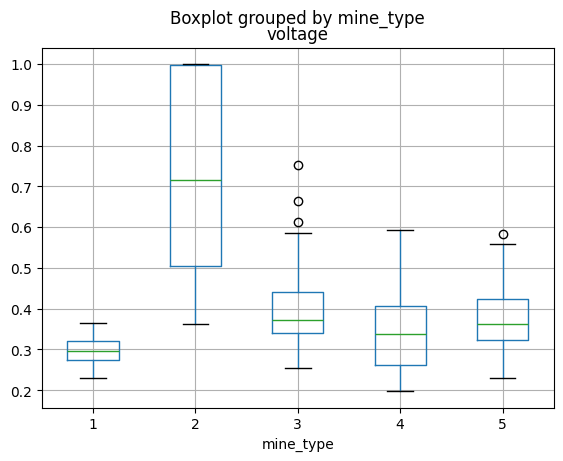

In [9]:
df.boxplot(column='voltage', by='mine_type')
plt.show()

There are 338 rows, 3 features (voltage, height, soil) the label mine_type, and no missing values. The five mine types are almost perfectly balanced (65 to 71 each), so a random guess would be right ~20% of the time. All the features are between 0 and 1, so I didn't rescale them for kNN. The average voltage differs signficiantly by mine type (type 2 is much higher than the rest), while the average height and soil are roughly the same for every type, so they look much less useful.

In [10]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
half = len(df) // 2

train = df.iloc[:half]
test = df.iloc[half:]

X_train = train[['voltage', 'height', 'soil']].values
y_train = train['mine_type'].values
X_test = test[['voltage', 'height', 'soil']].values
y_test = test['mine_type'].values

print(len(train), len(test))
print(np.bincount(y_train)[1:])
print(np.bincount(y_test)[1:])

169 169
[37 33 32 36 31]
[34 37 34 30 34]


In [11]:
def predict(x_new, k):
    distances = np.sqrt(((X_train - x_new) ** 2).sum(axis=1))
    nearest = np.argsort(distances)[:k]
    counts = np.bincount(y_train[nearest], minlength=6)
    return np.argmax(counts)

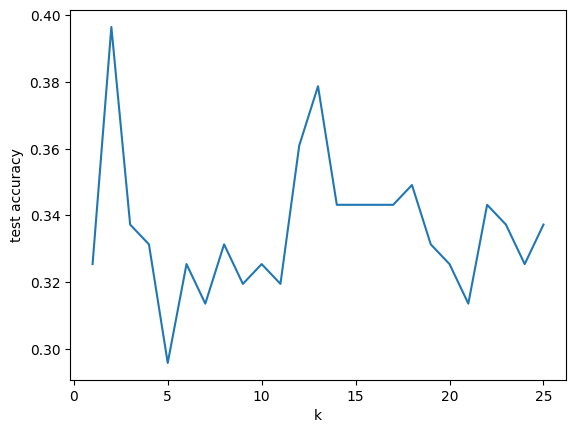

best k: 2 test accuracy: 0.39644970414201186


In [12]:
k_values = list(range(1, 26))
accuracies = []

for k in k_values:
    correct = 0
    for i in range(len(X_test)):
        if predict(X_test[i], k) == y_test[i]:
            correct = correct + 1
    accuracies.append(correct / len(X_test))

plt.plot(k_values, accuracies)
plt.xlabel('k')
plt.ylabel('test accuracy')
plt.show()

best_k = k_values[accuracies.index(max(accuracies))]
print('best k:', best_k, 'test accuracy:', max(accuracies))

I tried every k from 1 to 25, used the training set to find the neighbors, and measured the accuracy on the test set for each k. I picked the k with the highest test accuracy, which was k=2. The differences between neighboring values of k are small.

In [13]:
cm = np.zeros((5, 5), dtype=int)

for i in range(len(X_test)):
    actual = y_test[i]
    predicted = predict(X_test[i], best_k)
    cm[actual - 1, predicted - 1] = cm[actual - 1, predicted - 1] + 1

labels = [1, 2, 3, 4, 5]
print('rows = actual, columns = predicted')
print(pd.DataFrame(cm, index=labels, columns=labels))
print('accuracy:', cm.trace() / cm.sum())

rows = actual, columns = predicted
    1   2   3  4  5
1  22   0   6  6  0
2   0  28   3  5  1
3  15   2  11  5  1
4  13   4   5  6  2
5  13   1  12  8  0
accuracy: 0.39644970414201186


In [14]:
for j in range(5):
    recall = cm[j, j] / cm[j, :].sum()
    precision = cm[j, j] / cm[:, j].sum()
    print('type', j + 1, 'recall:', round(recall, 2), 'precision:', round(precision, 2))

type 1 recall: 0.65 precision: 0.35
type 2 recall: 0.76 precision: 0.8
type 3 recall: 0.32 precision: 0.3
type 4 recall: 0.2 precision: 0.2
type 5 recall: 0.0 precision: 0.0


With k=2 the accuracy on the test set is ~40%, twice as good as random guessing (20%), but still low.


Type 2 is the best performance: ~76% of real type 2 mines are found, and ~80% of type 2 predictions are correct. This makes sense because type 2 has a much higher voltage.

Type 1 is found often (65%), but it is over predicted. Many type 3, 4, and 5 mines get labeled as type 1, so only ~35% of type 1 predictions are correct.


Types 3 and 4 are weak (~32% and 20% found).

Type 5 is never predicted correctly (0 out of 34). These mines are mostly labeled as type 1 or type 3.

Because overall accuracy hides class-specific misclassifications and varying costs of false positives and false negatives, with the model failing ~ 60% of the time overall, its predictions shouldn't be treated as definitive. For example, while the model identifies 65% of actual Type 1 mines, its Type 1 predictions are correct only about 35% of the time due to frequent mislabeling of Types 3, 4, and 5. In contrast, Type 2 predictions are fairly reliable (~80% accuracy) for operational planning, but Type 1 and other labels must be viewed as rough guesses. Because Type 5 is never detected, no mine should ever be assumed harmless or categorized with certainty based on model output alone. When predictions are unclear, one should default to standard safety rules and the most conservative procedures. Ultimately, this model is best for supporting and prioritizing decisions made by experts rather than replace them.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]